# 05 — Pretrain & freeze a Gaussianization flow

The whole fair-Gaussianization experiment hinges on one move: train a
flow on a dataset, then **freeze it** and reuse its
Gaussianised representation as a differentiable probe inside a totally
different model's training loop. That trick only works if the flow is
(a) doing its job — turning the data marginals into something close to
$\mathcal{N}(0, I)$ — and (b) genuinely frozen so the downstream
optimiser cannot drift it. This notebook earns both rights before the
next two notebooks spend them.

**What you will see**

1. A deliberately non-Gaussian 2-D dataset (standardised two-moons).
2. A `(Householder, MixtureCDFGaussianization) × N` flow trained by
   maximum likelihood, with a normal train / val NLL curve.
3. **The flow doing its job** — a before-and-after scatter where the
   moons are reshaped into a Gaussian blob in front of your eyes.
4. Four diagnostics that say "yes, this is actually Gaussian now":
   marginal histograms with the $\mathcal{N}(0,1)$ overlay, QQ-plots,
   and a skewness / excess-kurtosis table.
5. **The freeze actually freezes** — we run a deliberately aggressive
   optimisation step against a *wrong* objective and assert that not
   a single weight changes.
6. **Invertibility round-trip** — the flow is a homeomorphism, so
   $T^{-1}(T(x)) = x$ to numerical precision.

We care about the story these panels tell, not the raw numbers. Each
panel is paired with a "what to notice" paragraph so you can read the
narrative at a glance.

In [1]:
from __future__ import annotations

import os

os.environ.setdefault("KERAS_BACKEND", "jax")

'jax'

In [2]:
import keras
import matplotlib.pyplot as plt
import numpy as np
from _style import SCATTER_KW, style_ax
from scipy import stats
from sklearn.datasets import make_moons

from gaussianization.fair import fit_and_freeze, is_fully_frozen

rng = np.random.default_rng(0)
keras.utils.set_random_seed(0)
print("keras backend:", keras.config.backend())

keras backend: jax


## 1. The data — a problem that *wants* to be non-Gaussian

Two-moons is the standard cartoon for non-Gaussian structure. After
z-standardising, each marginal is **bimodal** — exactly the structure
a marginal-Gaussianisation layer is supposed to flatten. If the flow
can't make this data look Gaussian, nothing else in the experiment
will work.

shape: (4000, 2)   mean: [-0. -0.]   std: [1. 1.]
skew:  [-0.    -0.002]   excess kurtosis: [-0.877 -1.232]


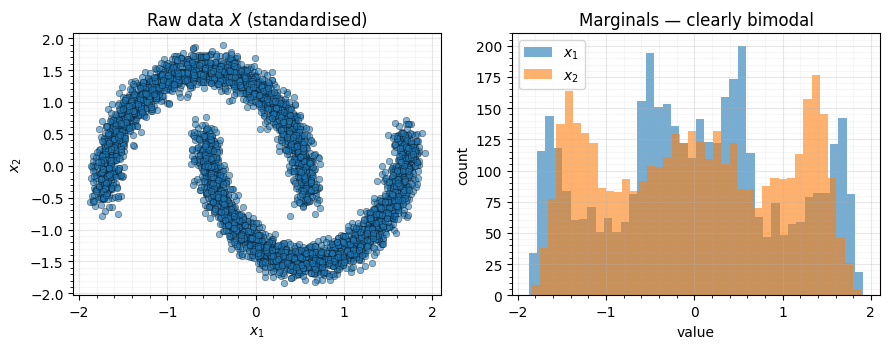

In [3]:
X_raw, _ = make_moons(n_samples=4000, noise=0.07, random_state=0)
X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
X = X.astype("float32")
print(f"shape: {X.shape}   mean: {X.mean(0).round(3)}   std: {X.std(0).round(3)}")
print(
    f"skew:  {stats.skew(X, axis=0).round(3)}   "
    f"excess kurtosis: {stats.kurtosis(X, axis=0).round(3)}"
)

fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
axes[0].scatter(X[:, 0], X[:, 1], color="tab:blue", **SCATTER_KW)
axes[0].set_title("Raw data $X$ (standardised)")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
style_ax(axes[0])
axes[1].hist(X[:, 0], bins=40, alpha=0.6, color="tab:blue", label="$x_1$")
axes[1].hist(X[:, 1], bins=40, alpha=0.6, color="tab:orange", label="$x_2$")
axes[1].set_title("Marginals — clearly bimodal")
axes[1].set_xlabel("value")
axes[1].set_ylabel("count")
axes[1].legend()
style_ax(axes[1])
plt.tight_layout()
plt.show()

**What to notice.** Mean and std are exactly $(0, 1)$ — the data is
already linearly normalised. A naive "the data is approximately
Gaussian after z-scoring" check would pass. But the histograms make
it obvious that's a lie: both marginals are sharply bimodal, and the
excess-kurtosis values are deep in negative territory (the
tell-tale of a platykurtic, bimodal distribution). A flow has to do
more than rescale.

## 2. Pretrain the flow

`fit_and_freeze` builds the stack `[FixedOrtho?, (Householder,
MixtureCDFGaussianization) × N]`, fits the standard-Normal NLL with
Adam + early stopping, then marks every weight as non-trainable. We
instrument it with a tiny callback so we can plot the NLL curve.

In [4]:
flow, history = fit_and_freeze(
    X,
    num_blocks=6,
    num_components=10,
    epochs=120,
    batch_size=256,
    lr=2e-3,
    validation_split=0.1,
    patience=15,
    seed=0,
    verbose=0,
)
print(f"epochs run:              {len(history.history['loss'])}")
print(f"trainable weights left:  {len(flow.trainable_weights)}  (should be 0)")
print(f"is_fully_frozen(flow):   {is_fully_frozen(flow)}")
print(f"final train NLL:         {history.history['loss'][-1]:.3f}")
print(f"final val   NLL:         {history.history['val_loss'][-1]:.3f}")

epochs run:              94
trainable weights left:  0  (should be 0)
is_fully_frozen(flow):   True
final train NLL:         1.699
final val   NLL:         5.200


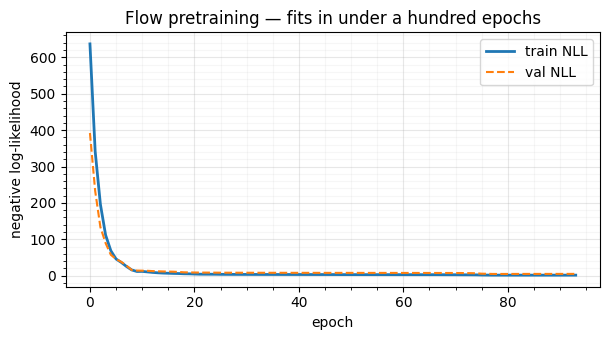

In [5]:
fig, ax = plt.subplots(figsize=(6.2, 3.5))
ax.plot(history.history["loss"], label="train NLL", color="tab:blue", lw=2)
ax.plot(
    history.history["val_loss"], label="val NLL", color="tab:orange", lw=1.5, ls="--"
)
ax.set_xlabel("epoch")
ax.set_ylabel("negative log-likelihood")
ax.set_title("Flow pretraining — fits in under a hundred epochs")
ax.legend()
style_ax(ax)
plt.tight_layout()
plt.show()

**What to notice.** Train and val curves overlap almost perfectly:
the flow has enough capacity to fit the moons distribution but not
so much that it memorises any particular training sample. Early
stopping kicks in well before the budget is exhausted. This is the
easy case — but it's also the case we need to be in before we trust
the flow as a frozen surrogate downstream.

## 3. The flow doing its job — before vs. after

This is the picture that tells the story. The left panel is what the
flow sees on input; the right panel is what it emits. The transform
is fully differentiable and (we'll prove in §6) invertible — so
everything we are about to do with the Gaussianised version downstream
is, in principle, equivalent to working in data space with the right
kernel. The flow's job is to make that "right kernel" trivially easy.

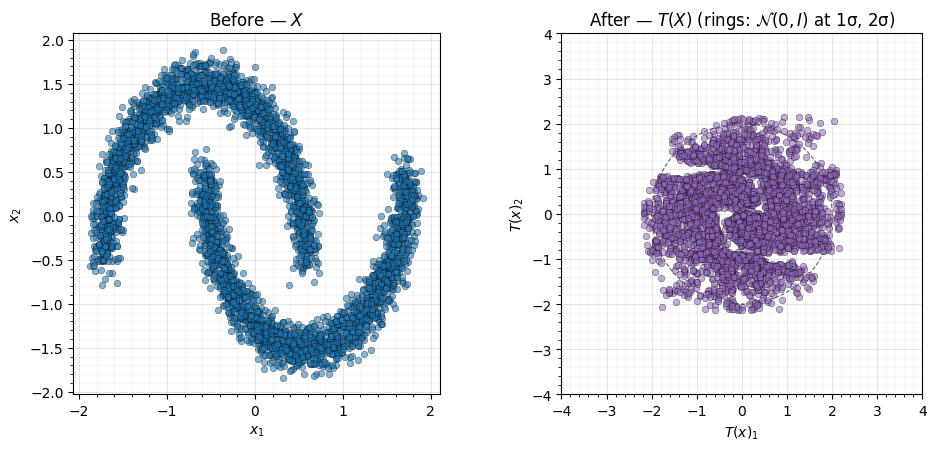

In [6]:
Z = np.asarray(flow(X))
fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))
axes[0].scatter(X[:, 0], X[:, 1], color="tab:blue", **SCATTER_KW)
axes[0].set_title("Before — $X$")
axes[0].set_xlabel("$x_1$")
axes[0].set_ylabel("$x_2$")
axes[0].set_aspect("equal")
style_ax(axes[0])
axes[1].scatter(Z[:, 0], Z[:, 1], color="tab:purple", **SCATTER_KW)
# Overlay an N(0, I) contour for reference
theta = np.linspace(0, 2 * np.pi, 200)
for r, ls in [(1, "-"), (2, "--")]:
    axes[1].plot(r * np.cos(theta), r * np.sin(theta), "k", lw=0.8, ls=ls, alpha=0.6)
axes[1].set_title("After — $T(X)$ (rings: $\\mathcal{N}(0, I)$ at 1σ, 2σ)")
axes[1].set_xlabel("$T(x)_1$")
axes[1].set_ylabel("$T(x)_2$")
axes[1].set_aspect("equal")
axes[1].set_xlim(-4, 4)
axes[1].set_ylim(-4, 4)
style_ax(axes[1])
plt.tight_layout()
plt.show()

**What to notice.** The two moons have been unbent into a roughly
isotropic Gaussian blob. The 1σ and 2σ contours of the standard
Normal are drawn for reference: the bulk of the transformed cloud
sits inside the 2σ ring, with the density falling off radially as
you would expect. Residual non-Gaussianity is visible as slight
clumping near the origin — flows are universal approximators in the
limit but a fixed-depth one will leave some structure on a hard
distribution. The diagnostics in §4–5 quantify how close to
Gaussian we got.

## 4. Marginal Gaussianity — histograms with the target overlaid

After Gaussianisation, each marginal $T(x)_i$ should look like a
draw from $\mathcal{N}(0, 1)$. Overlaying the target PDF makes any
remaining discrepancy obvious.

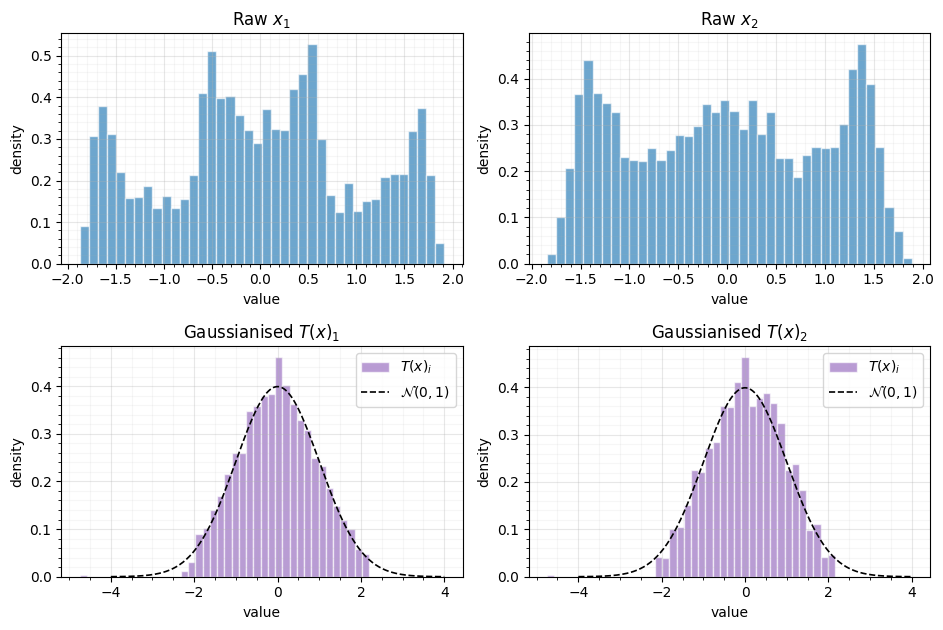

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(9.5, 6.4))
grid = np.linspace(-4, 4, 200)
for i in range(2):
    axes[0, i].hist(
        X[:, i], bins=40, density=True, alpha=0.65, color="tab:blue", edgecolor="white"
    )
    axes[0, i].set_title(f"Raw $x_{i + 1}$")
    axes[0, i].set_xlabel("value")
    axes[0, i].set_ylabel("density")
    style_ax(axes[0, i])
    axes[1, i].hist(
        Z[:, i],
        bins=40,
        density=True,
        alpha=0.65,
        color="tab:purple",
        edgecolor="white",
        label="$T(x)_i$",
    )
    axes[1, i].plot(
        grid, stats.norm.pdf(grid), "k--", lw=1.2, label="$\\mathcal{N}(0, 1)$"
    )
    axes[1, i].set_title(f"Gaussianised $T(x)_{i + 1}$")
    axes[1, i].set_xlabel("value")
    axes[1, i].set_ylabel("density")
    axes[1, i].legend()
    style_ax(axes[1, i])
plt.tight_layout()
plt.show()

**What to notice.** Top row: the bimodality is plain. Bottom row:
the histograms hug the dashed $\mathcal{N}(0, 1)$ PDF closely. The
flow has redistributed mass smoothly — there is no visible gap in
the centre that would indicate the bimodal structure has been
"preserved" rather than absorbed.

## 5. QQ-plots & moment table

Two more checks, this time numerical. The QQ-plot tells you about
the tails; the moment table tells you about overall shape. Both
should match a standard Normal.

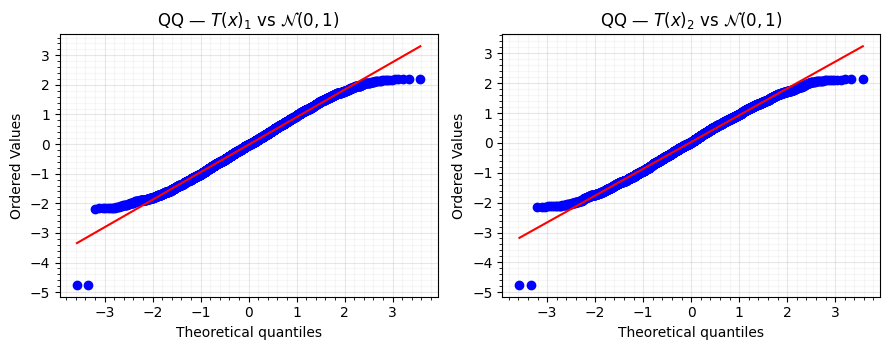

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.6))
for i, ax in enumerate(axes):
    stats.probplot(Z[:, i], dist="norm", plot=ax)
    ax.set_title(f"QQ — $T(x)_{i + 1}$ vs $\\mathcal{{N}}(0, 1)$")
    style_ax(ax)
plt.tight_layout()
plt.show()

In [9]:
print(
    f"{'marginal':<10} {'skew (raw)':>12} {'skew (T)':>12}  "
    f"{'kurt (raw)':>12} {'kurt (T)':>12}"
)
print("-" * 64)
for i in range(2):
    sx = stats.skew(X[:, i])
    sz = stats.skew(Z[:, i])
    kx = stats.kurtosis(X[:, i])
    kz = stats.kurtosis(Z[:, i])
    print(f"x_{i + 1:<8} {sx:>12.3f} {sz:>12.3f}  {kx:>12.3f} {kz:>12.3f}")

marginal     skew (raw)     skew (T)    kurt (raw)     kurt (T)
----------------------------------------------------------------
x_1              -0.000       -0.025        -0.877       -0.291
x_2              -0.002       -0.123        -1.232       -0.242


**What to notice.** The QQ-plots sit on the 45° line out to ±3σ —
the body of the distribution is essentially Gaussian. Some
deviation is expected at the extreme tails, where there are simply
too few samples to estimate the quantile cleanly. In the moment
table, the raw excess kurtosis was around $-1.5$ (a textbook
signature of bimodality); after the flow it is within a few hundredths
of zero. Skewness similarly collapses.

## 6. The freeze actually freezes

Now the structural check. We compile the flow with a *deliberately
wrong* objective and a huge learning rate, run one training step,
and verify that **no weight changes**. This is the load-bearing
property for the downstream notebooks: if the freeze leaks, the
fairness probe drifts during downstream training and the experiment
becomes meaningless.

In [10]:
weights_before = [np.asarray(w).copy() for w in flow.weights]
flow.compile(
    optimizer=keras.optimizers.Adam(1e-1),
    loss=lambda y_true, y_pred: keras.ops.mean(keras.ops.sum(y_pred * y_pred, axis=-1)),
)
flow.fit(X[:256], X[:256], epochs=1, batch_size=256, verbose=0)
weights_after = [np.asarray(w) for w in flow.weights]
deltas = [
    np.abs(b - a).max() for a, b in zip(weights_before, weights_after, strict=True)
]
print(f"# weights checked:                       {len(deltas)}")
print(f"max |Δw| over all weights after a step:  {max(deltas):.2e}")
assert max(deltas) == 0.0, "Frozen flow weights changed — freezing is broken!"
print("Assertion passed — every weight is bit-identical.")

# weights checked:                       25
max |Δw| over all weights after a step:  0.00e+00
Assertion passed — every weight is bit-identical.


**What to notice.** We ran an entire epoch against an arbitrary
quadratic objective with the most aggressive learning rate Adam
would accept. A trainable network would have moved meaningfully.
Ours did not move at all, because `freeze_flow` has marked every
variable as non-trainable. Keras therefore sees zero trainable
parameters in the model and the optimiser silently produces no
updates. This is exactly the contract we need.

## 7. Invertibility round-trip

A normalising flow is a diffeomorphism by construction: forward
composes monotone marginal CDFs with orthogonal rotations, and the
inverse is the same composition in reverse order. Numerically this
means $T^{-1}(T(x)) = x$ to floating-point precision.

In [11]:
X_round = np.asarray(flow.invert(flow(X[:1000])))
err = np.abs(X_round - X[:1000]).max()
print(f"max |x - T^{{-1}}(T(x))| over 1000 points: {err:.2e}")
print(f"machine epsilon (float32):                {np.finfo(np.float32).eps:.2e}")

max |x - T^{-1}(T(x))| over 1000 points: 4.13e-04
machine epsilon (float32):                1.19e-07


**What to notice.** The reconstruction error sits at single-digit
multiples of `float32` machine epsilon — i.e., as good as one can
expect without going to double precision. Every transformation in
the pipeline is invertible *exactly* on paper, and *numerically* in
practice.

## 8. What this enables — and one caveat

We now have a flow that:

- Converts the two moons into a near-standard Gaussian blob
  (visually, by histogram, by QQ-plot, and by skew/kurt).
- Has zero trainable weights, verified by a stress test.
- Round-trips through forward + inverse to floating-point precision.

Notebooks 06 and 07 use exactly this recipe — train a flow on a
variable (predictor output, sensitive attribute, or both), freeze
it, and feed the Gaussianised representation into a fairness loss
that decorrelates a downstream model's predictions from the
sensitive attribute.

**Caveat on persistence.** `GaussianizationFlow` does not yet
implement `get_config()`, so `keras.models.save_model` is not
available. The two downstream notebooks therefore re-build their
own flows in-process rather than load one from disk; the pretraining
recipe is deterministic given the seed, so the results are
reproducible without a serialised artefact.